# Self-crossing under the first mKdV flow

A closed **anti-oriented K12** with torsion angle $\mu=6/5$ can develop a transverse self-intersection under the first semi-discrete mKdV flow. At $t=0$, edges **0 and 6** meet in their interiors; immediately before and after, the curve is embedded.

The contact is certified by interval arithmetic. The animation and time-series plots are numerical DOP853 samples, with no collision avoidance or constraint projection.

This notebook uses standard **Gauss writhe**: $\mathrm{Lk}=\mathrm{Tw}+\mathrm{Wr}$ falls from $4.5$ to $2.5$. For this anti-oriented ribbon, the integer twisting number is $T=2\mathrm{Lk}$. Both Wr and Lk are undefined at the contact.

## Setup

Run from the repository with the package installed (`pip install -e '.[dev]'`). The repository's development interpreter is `/opt/homebrew/Caskroom/miniforge/base/envs/py313/bin/python`.

The exact decimal inputs and matrix are in `data/counterexamples/mkdv_self_crossing_k12.json`. All computations are exposed by modules in `src/kaleidocycle/`; this notebook is their executable companion.

In [1]:
%matplotlib widget
from io import BytesIO

import numpy as np
from IPython.display import Image, display
from kaleidocycle.collision_certificate import certify_crossing
from kaleidocycle.collisions import (
    crossing_velocity, load_crossing_data, reconstruct_crossing, sample_crossing,
)
from kaleidocycle.collision_visualization import (
    create_crossing_viewer, plot_crossing_diagnostics, plot_crossing_shapes,
    plot_crossing_detail,
)

source = load_crossing_data()
contact = reconstruct_crossing()
print(f"N = {source['n']}, mu = {source['torsion_angle']} rad, sign = {source['sign']}")

N = 12, mu = 1.2 rad, sign = -1


## Certify an exact crossing

Fix the five listed joint angles and solve the nine equations for position closure, frame closure and the interior contact. The other seven angles and the two edge fractions vary in a box of radius $10^{-20}$.

For the stored decimal centre $y_*$ and matrix $B$, the verifier bounds $\|Bf(y_*)\|_\infty<10^{-58}$ and $\sup_D\|I-BDf\|_\infty<10^{-15}$. Thus $y\mapsto y-Bf(y)$ is a contraction of the box into itself. The code also excludes the spurious half-turn branch of the skew frame equations, certifies all joints as regular, and separates all 53 other non-adjacent edge pairs.

In [2]:
certificate = certify_crossing()
for key, value in certificate.items():
    print(f"{key}: {value}")

verified: True
root_radius: 0.00000000000000000001
newton_correction_upper: 1e-58
contraction_upper: 1e-15
transverse_speed_bounds: [-3.283, -3.281]
other_edge_distance_lower: 0.0129
separated_edge_pairs: 53
interval_digits: 70
scope: Exact local contact and crossing; sampled trajectories are numerical.


### The first flow crosses the contact set

With $z_n=\tan(\phi_n/2)$, the lifted velocity is $V_n=F_n(\cos\mu,-z_n\cos\mu,-z_n\sin\mu)^T$. At the contact fractions $u,v$, set

$$W=(1-u)V_0+uV_1-(1-v)V_6-vV_7.$$

The certificate proves $-3.283<(T_0\times T_6)\cdot W<-3.281$. The Jacobian of the contact equation in $(t,u,v)$ is therefore invertible. Together with separation of every other edge pair, this proves an isolated crossing and embedded configurations immediately on either side. Taking a nearby negative time as the initial time gives the counterexample.

In [3]:
print("Contact fractions:", [float(v) for v in source["center"][-2:]])
print(f"Normal relative velocity: {crossing_velocity():.12f}")
print(f"Closure residual: {np.linalg.norm(contact.closure_residual):.3e}")
print(f"Frame residual: {np.linalg.norm(contact.monodromy_residual):.3e}")
print(f"Largest absolute joint angle: {np.max(abs(contact.angles)):.8f} < pi")

Contact fractions: [0.8214635512039877, 0.12251724458360418]
Normal relative velocity: -3.282340413857
Closure residual: 1.087e-15
Frame residual: 1.217e-15
Largest absolute joint angle: 2.71446673 < pi


## Follow the first flow through the contact

The package's `mkdv1_field` is integrated from $t=0$ in both directions. Reconstruction fixes the initial frame at the identity, so the displayed motion is considered modulo rigid motions. Edge length is one.

The following static figures remain readable without a widget-capable Jupyter front end. There is no line connecting Wr across its undefined value at zero.

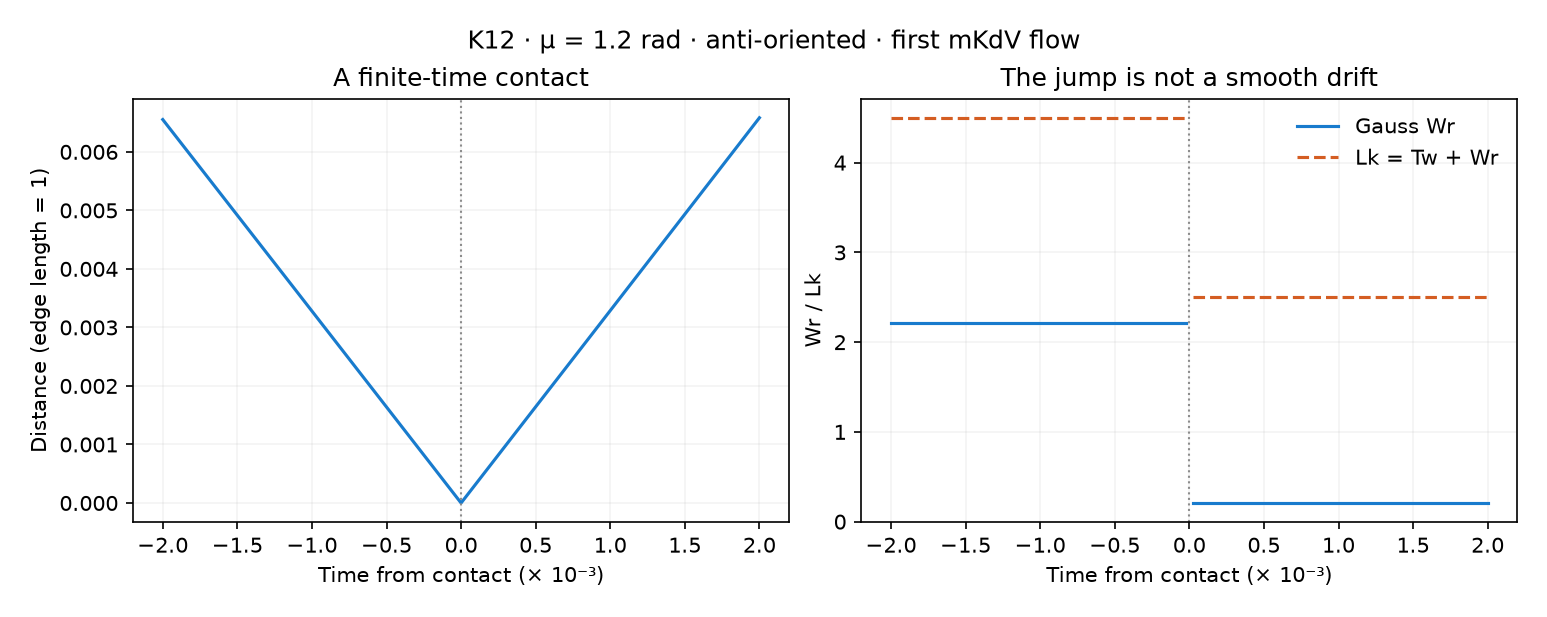

In [4]:
trajectory = sample_crossing(np.linspace(-0.002, 0.002, 161))
fig = plot_crossing_diagnostics(trajectory)
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", pad_inches=.2)
display(Image(data=buffer.getvalue()))

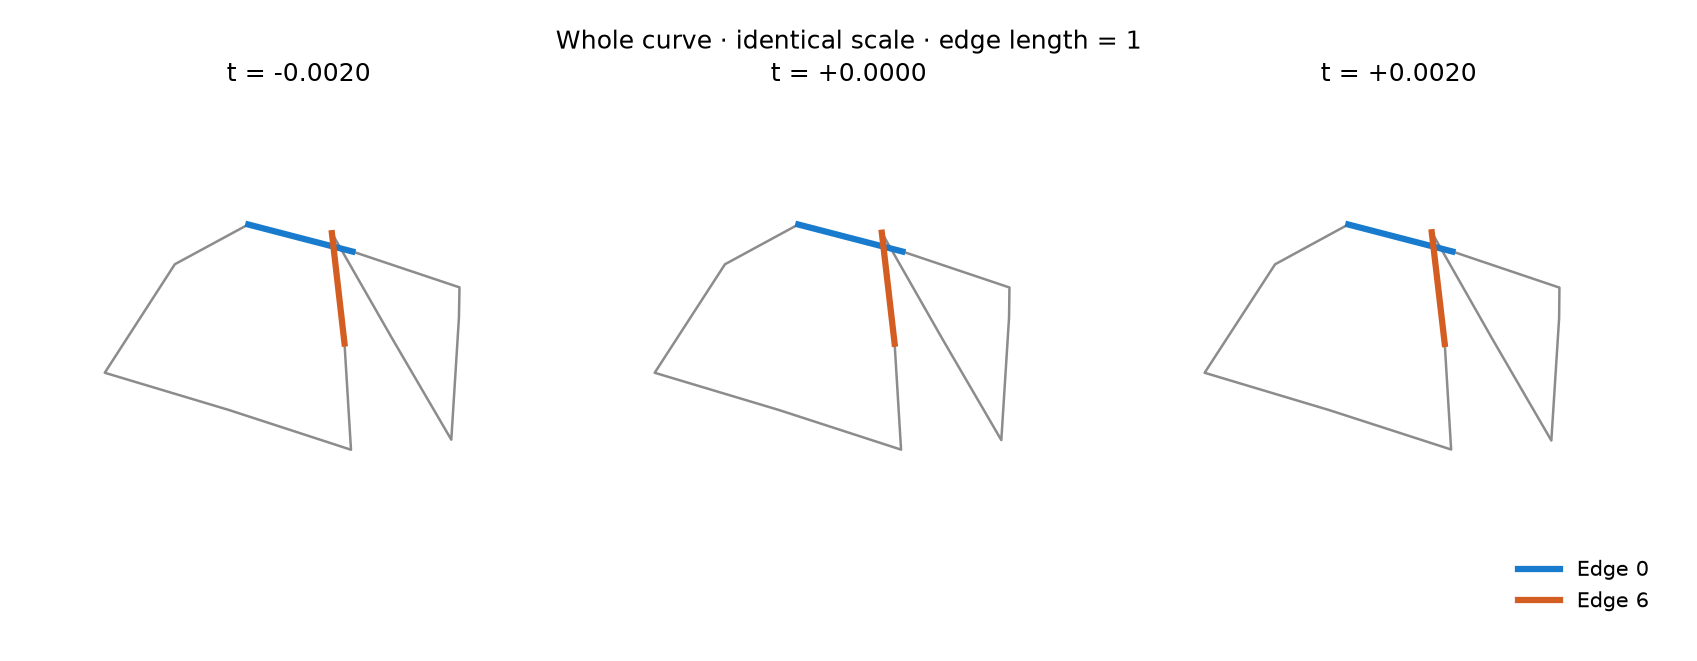

In [5]:
fig = plot_crossing_shapes(trajectory)
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", pad_inches=.2)
display(Image(data=buffer.getvalue()))

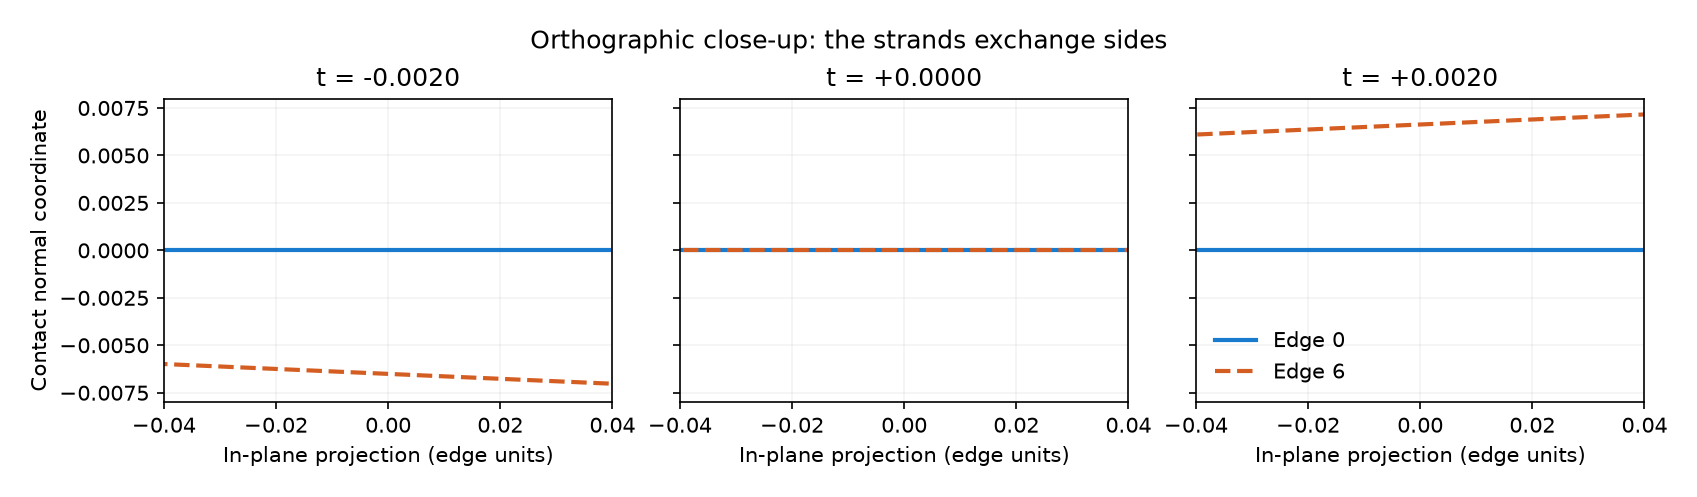

In [6]:
fig = plot_crossing_detail(trajectory)
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", pad_inches=.2)
display(Image(data=buffer.getvalue()))

### Rotate the curve and move through time

The blue segment is edge 0 and the orange segment is edge 6 (zero-based indexing). Use the time slider or go directly to the contact.

In [7]:
viewer = create_crossing_viewer(trajectory)
display(viewer)

## Numerical checks and scope

These numerical checks accompany the interval proof; they do not replace it. The certificate concerns the exact local crossing, not every point on an interval-integrated trajectory. The conventional Gauss normalisation used here is deliberately separate from the package's historical π-normalised `geometry.writhe` API.

In [8]:
rows = [0, len(trajectory.times)//2, len(trajectory.times)-1]
print("       t       min distance          Wr       Lk")
for i in rows:
    print(f"{trajectory.times[i]:+.6f}  {trajectory.min_distance[i]:.10f}  "
          f"{trajectory.writhe[i]:11.8f}  {trajectory.linking[i]:5.1f}")
print(f"Max closure error: {trajectory.closure.max():.3e}")
print(f"Max monodromy error: {trajectory.monodromy.max():.3e}")
print(f"First Hamiltonian drift: {np.ptp(trajectory.energy):.3e}")
assert certificate["verified"]
assert abs(trajectory.writhe[-1] - trajectory.writhe[0] + 2) < 1e-9
assert np.isnan(trajectory.writhe[len(trajectory.times)//2])
assert trajectory.closure.max() < 1e-10
assert trajectory.monodromy.max() < 1e-10

       t       min distance          Wr       Lk
-0.002000  0.0065522780   2.20816882    4.5
+0.000000  0.0000000000          nan    nan
+0.002000  0.0065825636   0.20816882    2.5
Max closure error: 1.958e-15
Max monodromy error: 1.728e-15
First Hamiltonian drift: 5.329e-15


## Consequence

Fixed torsion, closure, equal edge lengths and bounded joint angles do **not** imply preservation of embeddedness. Wr and Lk are constant on intervals where the ribbon stays embedded; they can jump when the curve passes through itself.

This example does not rule out embeddedness for a specially restricted family, such as a specified extremal-torsion component. Such a result needs a separate separation argument.

The interval checker is `src/kaleidocycle/collision_certificate.py`. Rebuild the shared sample and studio offline fallback with `python scripts/build_self_crossing.py`.

For conventions, see [Kaji–Kajiwara–Park, §5](https://arxiv.org/pdf/1903.06360).